In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import scipy
import time
import gget
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
from collections import Counter
from Bio import Align
from Bio import SeqIO
from Bio.Align import PairwiseAligner
import pysam
from difflib import SequenceMatcher
import scipy.sparse as sp
import scipy.stats as stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.patheffects as path_effects
import matplotlib.ticker as mtick

sc.settings.verbosity = 2
# sc.logging.print_header()

# Load data

In [2]:
%%time

fpath = "/scratch/indikar_root/indikar1/shared_data/HYB/endo_vs_exo/processed_all_groups_wExoEndo_v2.h5ad"

adata = sc.read_h5ad(fpath)
adata

CPU times: user 702 ms, sys: 2.37 s, total: 3.07 s
Wall time: 19.9 s


AnnData object with n_obs × n_vars = 16296 × 25128
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

# Load cell cycle genes

In [3]:
### --------- load cell cycle genes ---------

# regev
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
print(f'Total regev genes: {len(regev_genes)}')

s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

regev_genes = [g for g in regev_genes if g in adata.var_names]
print(f'\tDetected in adata: {len(regev_genes)}')


# GO
cdf = pd.read_csv("../../resources/human_cell_cycle_genes.csv")
cc_genes = cdf['gene_name'].unique()
print(f'\nTotal GO cell cycle genes: {len(cc_genes)}')
cc_genes = [g for g in cc_genes if g in adata.var_names]
print(f'\tDetected in adata: {len(cc_genes)}')


all_cc_genes = list(set(regev_genes) | set(cc_genes))
print(f'\nGenes in combined list: {len(all_cc_genes)}')

Total regev genes: 97
	Detected in adata: 94

Total GO cell cycle genes: 142
	Detected in adata: 120

Genes in combined list: 210


# Load DEG tables

In [4]:
fpath = "../../tables/DEGs_MyodExpLevels_HYB_G1S.csv"

hdf = pd.read_csv(fpath)
print(hdf.shape)
display(hdf.head())



fpath = "../../tables/DEGs_MyodExpLevels_mmMYOD1_G1S.csv"

mdf = pd.read_csv(fpath)
print(mdf.shape)
display(mdf.head())

(21850, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction
0,siPRRX1/mmMYOD1_high_G1S,MYOD1_exo,47.505005,35.085710,0.0,0.0,1.000000,Control_G1S,up
1,siPRRX1/mmMYOD1_high_G1S,MYOD1_endo,47.505005,34.325275,0.0,0.0,1.000000,Control_G1S,up
2,siPRRX1/mmMYOD1_high_G1S,MT-ND4,47.501183,2.978337,0.0,0.0,1.000000,Control_G1S,up
3,siPRRX1/mmMYOD1_high_G1S,MYOD1,46.688595,32.032375,0.0,0.0,0.982814,Control_G1S,up
4,siPRRX1/mmMYOD1_high_G1S,LINC-PINT,38.898235,2.623778,0.0,0.0,0.963480,Control_G1S,up


(21381, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction
0,mmMYOD1_high_G1S,MYOD1_exo,41.296528,36.265495,0.000000e+00,0.000000e+00,1.000000,Control_G1S,up
1,mmMYOD1_high_G1S,MYOD1_endo,41.296528,35.380703,0.000000e+00,0.000000e+00,1.000000,Control_G1S,up
2,mmMYOD1_high_G1S,MYOD1,41.172330,33.265804,0.000000e+00,0.000000e+00,0.996992,Control_G1S,up
3,mmMYOD1_high_G1S,MT-ND4,41.169952,3.180320,0.000000e+00,0.000000e+00,0.998496,Control_G1S,up
4,mmMYOD1_high_G1S,LINC-PINT,36.189045,3.098549,9.053250e-287,3.296958e-284,0.962406,Control_G1S,up


In [5]:
hdf = hdf[hdf['names'].isin(all_cc_genes)]
print(hdf.shape)

mdf = mdf[mdf['names'].isin(all_cc_genes)]
print(mdf.shape)

(405, 9)
(355, 9)


In [56]:
df = pd.concat([mdf, hdf])
print(df.shape)

df.head()

(760, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction
73,mmMYOD1_high_G1S,GMNN,23.052416,2.295428,1.391079e-117,9.874300e-116,0.769925,Control_G1S,up
113,mmMYOD1_high_G1S,PLK2,20.845648,3.490016,1.669341e-96,9.363212e-95,0.612030,Control_G1S,up
202,mmMYOD1_high_G1S,NES,18.075657,2.351126,4.956188e-73,1.939861e-71,0.592481,Control_G1S,up
208,mmMYOD1_high_G1S,MYC,17.782084,2.979373,9.729763e-71,3.738371e-69,0.538346,Control_G1S,up
399,mmMYOD1_high_G1S,FBXL7,13.908415,1.147300,5.631406e-44,1.333704e-42,0.718797,Control_G1S,up


In [58]:
df = df[df['logfoldchanges'].abs() >= 0.5]
print(df.shape)
df.head()

(636, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction
73,mmMYOD1_high_G1S,GMNN,23.052416,2.295428,1.391079e-117,9.874300e-116,0.769925,Control_G1S,up
113,mmMYOD1_high_G1S,PLK2,20.845648,3.490016,1.669341e-96,9.363212e-95,0.612030,Control_G1S,up
202,mmMYOD1_high_G1S,NES,18.075657,2.351126,4.956188e-73,1.939861e-71,0.592481,Control_G1S,up
208,mmMYOD1_high_G1S,MYC,17.782084,2.979373,9.729763e-71,3.738371e-69,0.538346,Control_G1S,up
399,mmMYOD1_high_G1S,FBXL7,13.908415,1.147300,5.631406e-44,1.333704e-42,0.718797,Control_G1S,up


In [59]:
df.groupby('group')['names'].nunique()

group
mmMYOD1_high_G1S             79
mmMYOD1_low_G1S             122
mmMYOD1_med_G1S              99
siPRRX1/mmMYOD1_high_G1S     88
siPRRX1/mmMYOD1_low_G1S     128
siPRRX1/mmMYOD1_med_G1S     120
Name: names, dtype: int64

In [62]:
# per group, how many DE cell cycle genes? How many UP/DOWN

counts = df.groupby(['group', 'direction'], observed=True).size().reset_index(name='count')
counts['count'] = counts.apply(lambda row: -row['count'] if row['direction'] == 'down' else row['count'], axis=1)
plot_df = counts.pivot(index='group', columns='direction', values='count').fillna(0)


vmax = plot_df.max().max()
vmin = plot_df.min().min()

group = 'mmMYOD1'

if group == 'mmMYOD1':
    ## mmMYOD1
    plot_df = plot_df.head(3)
if group == 'siPRRX1/mmMYOD1':
    plot_df = plot_df.tail(3)


plot_df.index = plot_df.index.str.split('_').str[-2].str.upper() 

plot_df

direction,down,up
group,,
HIGH,-30,49
LOW,-8,114
MED,-7,92


direction,down,up
group,,
LOW,-8,114
MED,-7,92
HIGH,-30,49


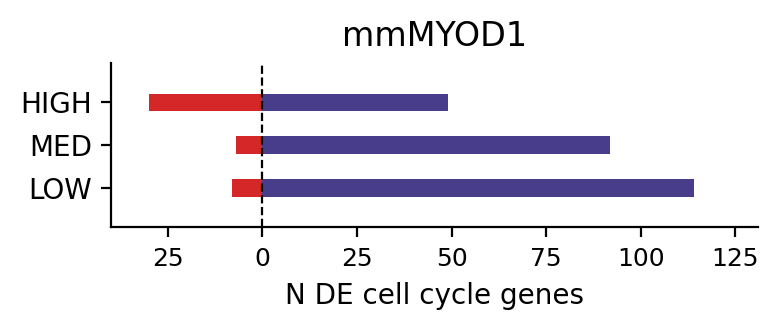

In [63]:
plot_order = ['LOW', 'MED', 'HIGH']
plot_df = plot_df.reindex(plot_order)
display(plot_df)

# plot
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 1.75
fig, ax = plt.subplots()

bar_width = 0.4

ax.barh(plot_df.index, plot_df['up'], color='darkslateblue', label='Up', height=bar_width)
ax.barh(plot_df.index, plot_df['down'], color='tab:red', label='Down', height=bar_width)

ax.axvline(0, color='k', linewidth=0.8, ls='--')

ax.set_xlabel("")
ax.set_ylabel("")

ax.set_yticks(range(len(plot_df.index)))
ax.set_yticklabels(plot_order)
ax.margins(y=0.3)


ax.set_xlim([vmin-10, vmax+10])

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: int(abs(x))))
ax.tick_params(axis='x', labelsize=9)

ax.set_title(f'{group}')

ax.set_xlabel('N DE cell cycle genes')

sns.despine()
plt.tight_layout()
plt.show()

In [64]:
counts = df.groupby(['group', 'direction'], observed=True).size().reset_index(name='count')
counts['count'] = counts.apply(lambda row: -row['count'] if row['direction'] == 'down' else row['count'], axis=1)
plot_df = counts.pivot(index='group', columns='direction', values='count').fillna(0)

plot_df['total'] = -plot_df['down'] + plot_df['up']

total_cc_genes = len(all_cc_genes)
print(total_cc_genes)

plot_df['prop_of_all'] = plot_df['total'] / total_cc_genes

plot_df


210


direction,down,up,total,prop_of_all
group,,,,
mmMYOD1_high_G1S,-30,49,79,0.376190
mmMYOD1_low_G1S,-8,114,122,0.580952
mmMYOD1_med_G1S,-7,92,99,0.471429
siPRRX1/mmMYOD1_high_G1S,-10,78,88,0.419048
siPRRX1/mmMYOD1_low_G1S,-7,121,128,0.609524
siPRRX1/mmMYOD1_med_G1S,-6,114,120,0.571429


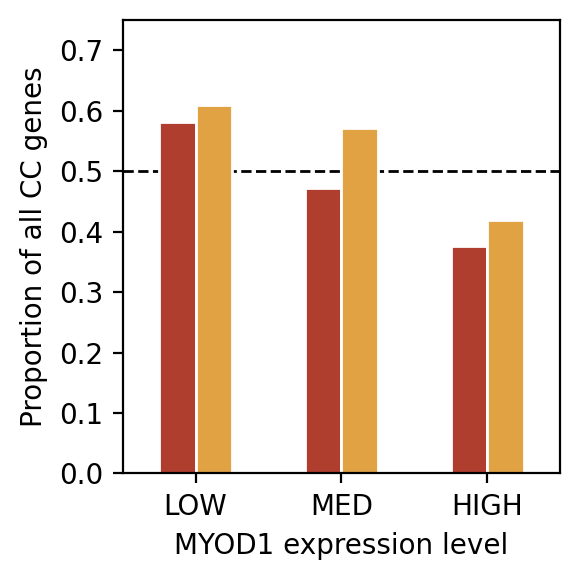

In [65]:
# Reset index for plotting
pdf = plot_df.reset_index()

pdf['condition'] = pdf['group'].str.split('_').str[0]
pdf['exp_level'] = pdf['group'].str.split('_').str[-2].str.upper()

pdf.head()


plt.figure(figsize=(3, 3), dpi=200)

colors = {'mmMYOD1': '#C52E19', 'siPRRX1/mmMYOD1': '#FBA72A'}

sns.barplot(
    data=pdf,
    x='exp_level',
    y='prop_of_all',
    hue='condition',
    order=['LOW', 'MED', 'HIGH'],
    palette=colors,
    legend=False,
    width=0.5,
    ec='white',
)

plt.ylim([0.0, 0.75])

plt.axhline(y=0.5, ls='--', color='k', lw=1, zorder=0)

# plt.xticks(rotation=45, ha='right')
plt.ylabel('Proportion of all CC genes')
plt.xlabel('MYOD1 expression level')
plt.tight_layout()
plt.show()

In [67]:
N = len(all_cc_genes) # total number of cell cycle genes tested

tmp = plot_df.copy()
tmp = tmp.reset_index()

tmp['exp_level'] = tmp['group'].str.split('_').str[-2].str.upper()
tmp['condition'] = tmp['group'].str.split('_').str[-3]

for cond in tmp['condition'].unique():
    
    print(f'{cond}:')
    
    tmp1 = tmp[tmp['condition'] == cond]
    
    high = tmp1.loc[tmp1['exp_level'] == 'HIGH', 'prop_of_all'].values[0]
    med = tmp1.loc[tmp1['exp_level'] == 'MED', 'prop_of_all'].values[0]
    low = tmp1.loc[tmp1['exp_level'] == 'LOW', 'prop_of_all'].values[0]
    
    high_low_diff = low - high
    avg_drop = ((low - med) + (med - high)) / 2
    
    print(f'Δ LOW → HIGH = {high_low_diff:.4f}')
    print(f'Δ LOW → MED = {(low - med):.4f}')
    print(f'Δ MED → HIGH = {(med - high):.4f}')
    print(f'Per-step average drop (LOW → MED, MED → HIGH) = {avg_drop:.4f}\n')


mmMYOD1:
Δ LOW → HIGH = 0.2048
Δ LOW → MED = 0.1095
Δ MED → HIGH = 0.0952
Per-step average drop (LOW → MED, MED → HIGH) = 0.1024

siPRRX1/mmMYOD1:
Δ LOW → HIGH = 0.1905
Δ LOW → MED = 0.0381
Δ MED → HIGH = 0.1524
Per-step average drop (LOW → MED, MED → HIGH) = 0.0952



In [16]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [68]:
N = len(all_cc_genes) # total number of cell cycle genes tested

tmp = plot_df.copy()
tmp = tmp.reset_index()

tmp['exp_level'] = tmp['group'].str.split('_').str[-2].str.upper()
tmp['condition'] = tmp['group'].str.split('_').str[-3]

level_map = {'LOW': 0, 'MED': 1, 'HIGH': 2}

tmp['level_ord'] = tmp['exp_level'].map(level_map)

tmp['fail'] = N - tmp['total']

# Main-effects model: one overall monotonic trend + condition shift
m1 = smf.glm('prop_of_all ~ level_ord + C(condition)',
             data=tmp,
             family=sm.families.Binomial(),
             freq_weights=np.repeat(N, len(tmp))  # treat each row as N trials
            ).fit()

print(m1.summary())

# Quantifying number: odds ratio per one-step increase (LOW->MED or MED->HIGH)
beta = m1.params['level_ord']
se = m1.bse['level_ord']
OR = np.exp(beta)
CI = np.exp([beta - 1.96*se, beta + 1.96*se])
print("OR per MYOD1 level step:", OR, "95% CI:", CI)

                 Generalized Linear Model Regression Results                  
Dep. Variable:            prop_of_all   No. Observations:                    6
Model:                            GLM   Df Residuals:                     1257
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -559.42
Date:                Wed, 29 Apr 2026   Deviance:                       1.8478
Time:                        12:42:13   Pearson chi2:                     1.85
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9980
Covariance Type:            nonrobust                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

In [69]:
pred_grid = pd.DataFrame({
    'level_ord': [0,1,2]*2,
    'condition': ['mmMYOD1']*3 + ['siPRRX1/mmMYOD1']*3
})
pred = m1.get_prediction(pred_grid).summary_frame()
pred_grid['p_hat'] = pred['mean']
pred_grid['p_lo']  = pred['mean_ci_lower']
pred_grid['p_hi']  = pred['mean_ci_upper']
print(pred_grid)

   level_ord        condition     p_hat      p_lo      p_hi
0          0          mmMYOD1  0.575429  0.523715  0.625543
1          1          mmMYOD1  0.475551  0.436269  0.515139
2          2          mmMYOD1  0.377591  0.329332  0.428406
3          0  siPRRX1/mmMYOD1  0.631587  0.581032  0.679407
4          1  siPRRX1/mmMYOD1  0.534226  0.494624  0.573402
5          2  siPRRX1/mmMYOD1  0.434187  0.383773  0.486000


In [70]:
m2 = smf.glm('prop_of_all ~ level_ord * C(condition)',
             data=tmp,
             family=sm.families.Binomial(),
             freq_weights=np.repeat(N, len(tmp))
            ).fit()

# Likelihood ratio test: does interaction improve fit?
lr = 2*(m2.llf - m1.llf)
df_diff = m2.df_model - m1.df_model
from scipy.stats import chi2
p = chi2.sf(lr, df_diff)
print("LR test interaction p =", p)

LR test interaction p = 0.8374881636859227


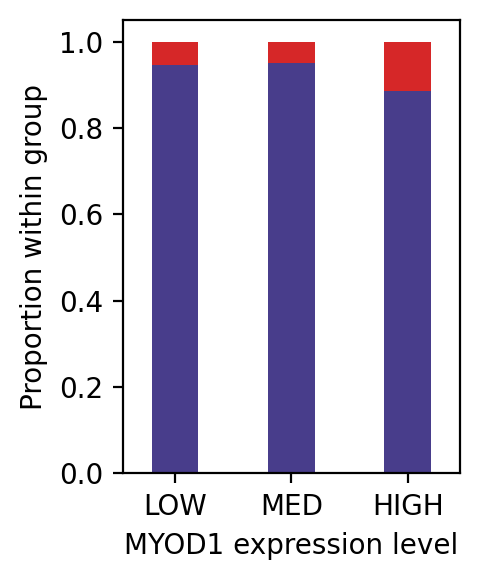

In [72]:
prop_df = plot_df.copy()

prop_df['up_prop'] = prop_df['up'] / prop_df['total']
prop_df['down_prop'] = (-prop_df['down']) / prop_df['total']  # flip sign back

# Keep only what we need
prop_df = prop_df[['up_prop', 'down_prop']]

group = 'siPRRX1/mmMYOD1'

if group == 'mmMYOD1':
    ## mmMYOD1
    prop_df = prop_df.head(3)
if group == 'siPRRX1/mmMYOD1':
    prop_df = prop_df.tail(3)


prop_df.index = prop_df.index.str.split('_').str[-2].str.upper() 
prop_df = prop_df.reindex(['LOW', 'MED', 'HIGH'])

plt.figure(figsize=(2.5, 3), dpi=200)

palette = ['darkslateblue', 'tab:red']

# Plot stacked bars
prop_df.plot(
    kind='bar',
    stacked=True,
    ax=plt.gca(),
    legend=False,
    color=palette,
    width=0.4,
)

plt.xticks(rotation=0)
plt.ylabel('Proportion within group')
plt.xlabel('MYOD1 expression level')


plt.tight_layout()
plt.show()

In [80]:
### within each group, how correlated are logFCs for the same genes

df.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction
73,mmMYOD1_high_G1S,GMNN,23.052416,2.295428,1.391079e-117,9.874300e-116,0.769925,Control_G1S,up
113,mmMYOD1_high_G1S,PLK2,20.845648,3.490016,1.669341e-96,9.363212e-95,0.612030,Control_G1S,up
202,mmMYOD1_high_G1S,NES,18.075657,2.351126,4.956188e-73,1.939861e-71,0.592481,Control_G1S,up
208,mmMYOD1_high_G1S,MYC,17.782084,2.979373,9.729763e-71,3.738371e-69,0.538346,Control_G1S,up
399,mmMYOD1_high_G1S,FBXL7,13.908415,1.147300,5.631406e-44,1.333704e-42,0.718797,Control_G1S,up


In [73]:
df['condition'] = df['group'].str.split('_').str[0]
df['exp_level'] = df['group'].str.split('_').str[-2].str.upper()

df.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction,condition,exp_level
73,mmMYOD1_high_G1S,GMNN,23.052416,2.295428,1.391079e-117,9.874300e-116,0.769925,Control_G1S,up,mmMYOD1,HIGH
113,mmMYOD1_high_G1S,PLK2,20.845648,3.490016,1.669341e-96,9.363212e-95,0.612030,Control_G1S,up,mmMYOD1,HIGH
202,mmMYOD1_high_G1S,NES,18.075657,2.351126,4.956188e-73,1.939861e-71,0.592481,Control_G1S,up,mmMYOD1,HIGH
208,mmMYOD1_high_G1S,MYC,17.782084,2.979373,9.729763e-71,3.738371e-69,0.538346,Control_G1S,up,mmMYOD1,HIGH
399,mmMYOD1_high_G1S,FBXL7,13.908415,1.147300,5.631406e-44,1.333704e-42,0.718797,Control_G1S,up,mmMYOD1,HIGH


In [74]:
from scipy.stats import pearsonr, spearmanr

In [75]:
cond = 'mmMYOD1'

tmp = df[df['condition'] == cond].copy()

high = tmp[tmp['exp_level'] == 'HIGH']['names'].unique()
med = tmp[tmp['exp_level'] == 'MED']['names'].unique()
low = tmp[tmp['exp_level'] == 'LOW']['names'].unique()

shared_genes = list(set(high) & set(med) & set(low))
print(len(shared_genes))


tmp = tmp[tmp['names'].isin(shared_genes)]

wdf = (
    tmp[["names", "exp_level", "logfoldchanges"]]
      .drop_duplicates(subset=["names", "exp_level"])   # in case a gene appears twice for a group
      .pivot(index="names", columns="exp_level", values="logfoldchanges")
      .rename(columns={
          'LOW':  "logFC_low",
          'MED':  "logFC_med",
          'HIGH': "logFC_high",
      })
)

print(wdf.shape)
wdf.head() 

50
(50, 3)


exp_level,logFC_high,logFC_low,logFC_med
names,,,
APP,-2.664147,-2.017786,-2.156026
AURKA,1.788099,1.733187,1.971897
BIRC5,-0.588815,1.081817,0.507158
BLM,1.876448,1.907166,1.947972
BRIP1,1.397962,1.996935,1.824856


In [76]:
corr = wdf.corr(method='pearson')
corr

exp_level,logFC_high,logFC_low,logFC_med
exp_level,,,
logFC_high,1.000000,0.864838,0.956292
logFC_low,0.864838,1.000000,0.962167
logFC_med,0.956292,0.962167,1.000000


In [77]:
corr = wdf.corr(method='spearman')
corr

exp_level,logFC_high,logFC_low,logFC_med
exp_level,,,
logFC_high,1.000000,0.773541,0.894550
logFC_low,0.773541,1.000000,0.919712
logFC_med,0.894550,0.919712,1.000000


In [9]:
df.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction,condition,exp_level
73,mmMYOD1_high_G1S,GMNN,23.052416,2.295428,1.391079e-117,9.874300e-116,0.769925,Control_G1S,up,mmMYOD1,HIGH
113,mmMYOD1_high_G1S,PLK2,20.845648,3.490016,1.669341e-96,9.363212e-95,0.612030,Control_G1S,up,mmMYOD1,HIGH
202,mmMYOD1_high_G1S,NES,18.075657,2.351126,4.956188e-73,1.939861e-71,0.592481,Control_G1S,up,mmMYOD1,HIGH
208,mmMYOD1_high_G1S,MYC,17.782084,2.979373,9.729763e-71,3.738371e-69,0.538346,Control_G1S,up,mmMYOD1,HIGH
399,mmMYOD1_high_G1S,FBXL7,13.908415,1.147300,5.631406e-44,1.333704e-42,0.718797,Control_G1S,up,mmMYOD1,HIGH


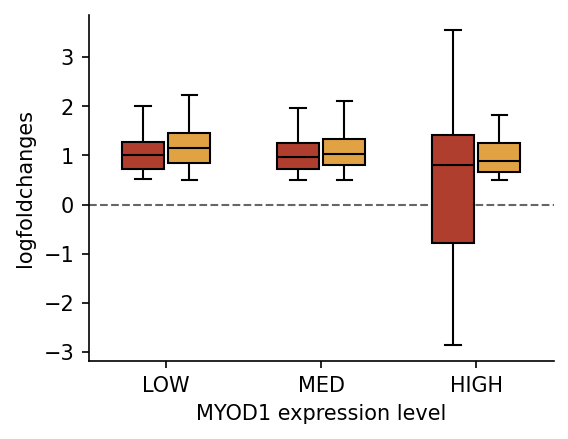

In [94]:
plt.figure(figsize=(4, 3), dpi=150)

colors = {'mmMYOD1': '#C52E19', 'siPRRX1/mmMYOD1': '#FBA72A'}

sns.boxplot(
    df,
    x='exp_level',
    y='logfoldchanges',
    hue='condition',
    order=['LOW', 'MED', 'HIGH'],
    palette=colors,
    legend=False,
    showfliers=False, 
    gap=0.1,
    width=0.6,
    linecolor='k',
    capwidths=0.1,
)

plt.xlabel('MYOD1 expression level')

plt.axhline(y=0, ls='--', color='k', lw=1, alpha=0.6, zorder=0)

sns.despine()
plt.show()

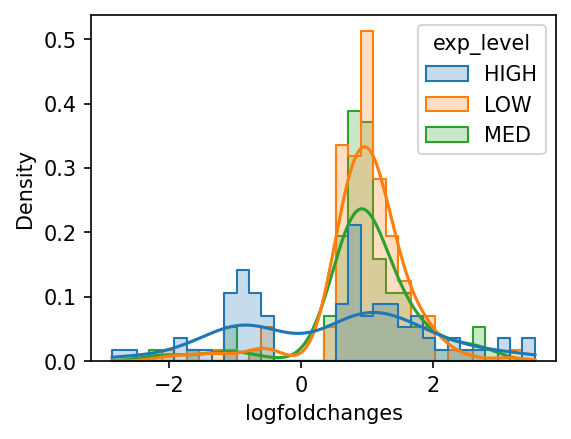

In [162]:
plt.figure(figsize=(4, 3), dpi=150)

cond = 'mmMYOD1'

tmp = df[df['condition'] == cond]

sns.histplot(
    tmp,
    x='logfoldchanges',
    kde=True,
    hue='exp_level',
    element='step',
    stat='density',
)

plt.show()

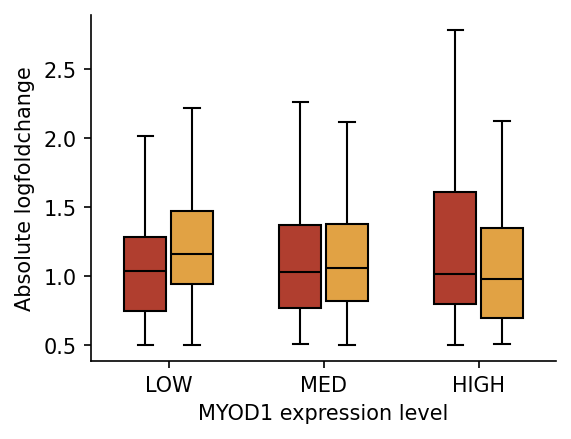

In [95]:
df['abs_lfc'] = df['logfoldchanges'].apply(abs)

plt.figure(figsize=(4, 3), dpi=150)

colors = {'mmMYOD1': '#C52E19', 'siPRRX1/mmMYOD1': '#FBA72A'}

sns.boxplot(
    df,
    x='exp_level',
    y='abs_lfc',
    hue='condition',
    order=['LOW', 'MED', 'HIGH'],
    palette=colors,
    legend=False,
    showfliers=False, 
    gap=0.1,
    width=0.6,
    linecolor='k',
    capwidths=0.1,
)

plt.xlabel('MYOD1 expression level')
plt.ylabel('Absolute logfoldchange')
# plt.axhline(y=0, ls='--', color='k', lw=1, alpha=0.6, zorder=0)

sns.despine()
plt.show()

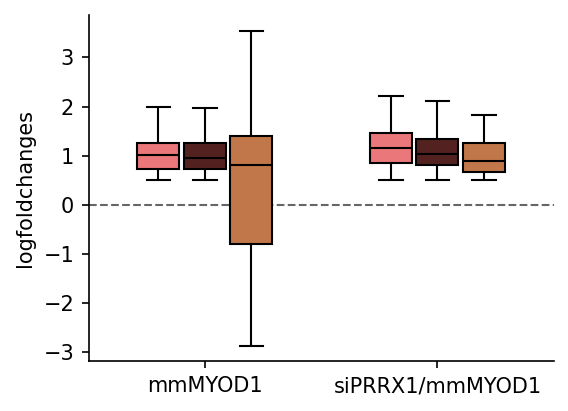

In [96]:
plt.figure(figsize=(4, 3), dpi=150)

colors = {
    'LOW': '#FD6467',
    'MED': '#5B1A18',
    'HIGH': '#D67236',
}

sns.boxplot(
    df,
    x='condition',
    y='logfoldchanges',
    hue='exp_level',
    hue_order=['LOW', 'MED', 'HIGH'],
    palette=colors,
    legend=False,
    showfliers=False, 
    gap=0.1,
    width=0.6,
    linecolor='k',
    capwidths=0.1,
)

plt.xlabel('')

plt.axhline(y=0, ls='--', color='k', lw=1, alpha=0.6, zorder=0)

sns.despine()
plt.show()

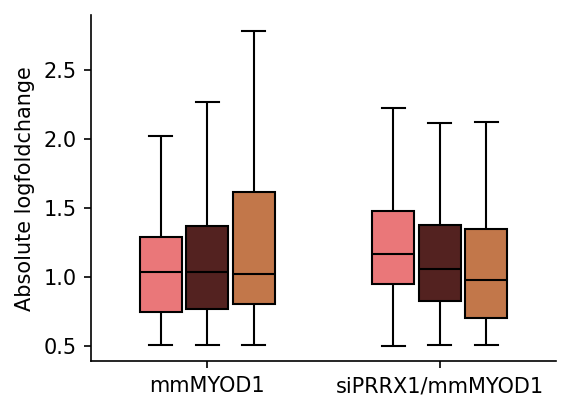

In [97]:
plt.figure(figsize=(4, 3), dpi=150)

colors = {
    'LOW': '#FD6467',
    'MED': '#5B1A18',
    'HIGH': '#D67236',
}

sns.boxplot(
    df,
    x='condition',
    y='abs_lfc',
    hue='exp_level',
    hue_order=['LOW', 'MED', 'HIGH'],
    palette=colors,
    legend=False,
    showfliers=False, 
    gap=0.1,
    width=0.6,
    linecolor='k',
    capwidths=0.1,
)

plt.xlabel('')
plt.ylabel('Absolute logfoldchange')

sns.despine()
plt.show()

In [39]:
df.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction,condition,exp_level,abs_lfc
73,mmMYOD1_high_G1S,GMNN,23.052416,2.295428,1.391079e-117,9.874300e-116,0.769925,Control_G1S,up,mmMYOD1,HIGH,2.295428
113,mmMYOD1_high_G1S,PLK2,20.845648,3.490016,1.669341e-96,9.363212e-95,0.612030,Control_G1S,up,mmMYOD1,HIGH,3.490016
202,mmMYOD1_high_G1S,NES,18.075657,2.351126,4.956188e-73,1.939861e-71,0.592481,Control_G1S,up,mmMYOD1,HIGH,2.351126
208,mmMYOD1_high_G1S,MYC,17.782084,2.979373,9.729763e-71,3.738371e-69,0.538346,Control_G1S,up,mmMYOD1,HIGH,2.979373
399,mmMYOD1_high_G1S,FBXL7,13.908415,1.147300,5.631406e-44,1.333704e-42,0.718797,Control_G1S,up,mmMYOD1,HIGH,1.147300


In [176]:
group_key = 'mmMYOD1'

groups_keep = [f'{group_key}_low_G1S', f'{group_key}_high_G1S']

direction = 'down'

tmp = df[df['direction'] == direction].copy()


wdf = (
    tmp.loc[tmp["group"].isin(groups_keep), ["names", "group", "logfoldchanges"]]
      .drop_duplicates(subset=["names", "group"])   # in case a gene appears twice for a group
      .pivot(index="names", columns="group", values="logfoldchanges")
      .rename(columns={
          f'{group_key}_low_G1S':  "logFC_low",
          f'{group_key}_high_G1S': "logFC_high",
      })
)

if direction == 'down':
    wdf = wdf.abs()

print(wdf.shape)
wdf.head()

(31, 2)


group,logFC_high,logFC_low
names,,
ANP32E,0.606470,NaN
APP,2.664147,2.017786
BIRC5,0.588815,NaN
CALM1,0.801251,NaN
CALM2,0.757849,NaN


N shared downregulated genes: 7
(7, 3)


group,logFC_high,logFC_low,delta_high_low
names,,,
APP,2.664147,2.017786,0.646361
CALM3,1.892928,0.677959,1.214969
CUL4B,0.940254,0.504841,0.435413
EIF4EBP1,1.794431,1.158701,0.635730
ITGB1,2.864909,1.342566,1.522344


% stronger in HIGH: 85.71%



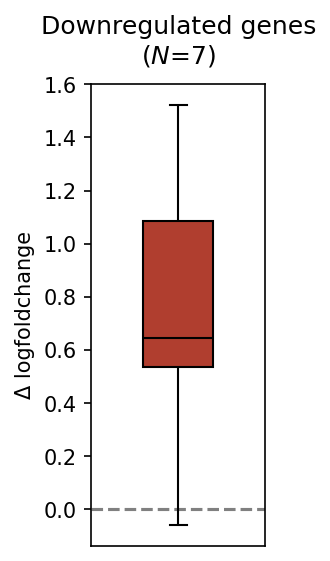

In [177]:
wdf1 = wdf.dropna(subset=['logFC_low', 'logFC_high']).copy()
print(f'N shared {direction}regulated genes: {len(wdf1)}')

wdf1['delta_high_low'] = wdf1['logFC_high'] - wdf1['logFC_low']

print(wdf1.shape)
display(wdf1.head())

if group_key == 'mmMYOD1':
    color = '#C52E19'
elif group_key == 'siPRRX1/mmMYOD1':
    color = '#FBA72A'
else:
    color='white'

    
wdf2 = wdf1.copy()
wdf2['pos_delta'] = wdf2['delta_high_low'] > 0
print(f"% stronger in HIGH: {wdf2['pos_delta'].sum()/len(wdf2)*100:.2f}%\n")

plt.figure(figsize=(1.5, 4), dpi=150)

sns.boxplot(
    wdf1,
    y='delta_high_low',
    width=0.4,
    color=color,
    linecolor='k',
    fliersize=3,
    capwidths=0.1,
    # showfliers=False,
)

plt.ylabel("Δ logfoldchange")
plt.gca().tick_params(axis='x', bottom=False)

plt.axhline(y=0, ls='--', color='gray', zorder=0)

if direction == 'up':
    plt.title(f"Upregulated genes\n($N$={len(wdf1)})", pad=10)
    
if direction == 'down':
    plt.title(f"Downregulated genes\n($N$={len(wdf1)})", pad=10)
    
plt.show()

In [ ]:
### upset plots for matches/mismatches / unique 

In [182]:
group_key = 'siPRRX1/mmMYOD1'
group_key = 'mmMYOD1'

groups_keep = [f'{group_key}_low_G1S', f'{group_key}_high_G1S']

kdf = df[df['group'].isin(groups_keep)].copy()
print(kdf.shape)


# Step 1: build a per-gene summary of directions across groups
gene_summary = (
    kdf.groupby('names')
      .agg(
          n_groups=('group', 'nunique'),
          n_directions=('direction', lambda x: x.nunique()),
          direction_set=('direction', lambda x: set(x))
      )
      .reset_index()
)

# Step 2: define logic for consistency
def classify(row):
    if row['n_groups'] == 1:
        return 'unique_to_group'
    elif row['n_directions'] == 1:
        return 'match'
    else:
        return 'mismatch'

gene_summary['direction_consistency'] = gene_summary.apply(classify, axis=1)

# Step 3: map back to original dataframe
kdf = kdf.merge(
    gene_summary[['names', 'direction_consistency']],
    on='names',
    how='left'
)

kdf.head()

(201, 12)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction,condition,exp_level,abs_lfc,direction_consistency
0,mmMYOD1_high_G1S,GMNN,23.052416,2.295428,1.391079e-117,9.874300e-116,0.769925,Control_G1S,up,mmMYOD1,HIGH,2.295428,match
1,mmMYOD1_high_G1S,PLK2,20.845648,3.490016,1.669341e-96,9.363212e-95,0.612030,Control_G1S,up,mmMYOD1,HIGH,3.490016,match
2,mmMYOD1_high_G1S,NES,18.075657,2.351126,4.956188e-73,1.939861e-71,0.592481,Control_G1S,up,mmMYOD1,HIGH,2.351126,match
3,mmMYOD1_high_G1S,MYC,17.782084,2.979373,9.729763e-71,3.738371e-69,0.538346,Control_G1S,up,mmMYOD1,HIGH,2.979373,match
4,mmMYOD1_high_G1S,FBXL7,13.908415,1.147300,5.631406e-44,1.333704e-42,0.718797,Control_G1S,up,mmMYOD1,HIGH,1.147300,match


In [183]:
print(kdf['names'].nunique())

print("\n", kdf.groupby('group')['names'].nunique())

print("\n", kdf.groupby(['group', 'direction'])['names'].nunique())

print("\n", kdf.groupby('group')['direction_consistency'].value_counts())

142

 group
mmMYOD1_high_G1S     79
mmMYOD1_low_G1S     122
Name: names, dtype: int64

 group             direction
mmMYOD1_high_G1S  down          30
                  up            49
mmMYOD1_low_G1S   down           8
                  up           114
Name: names, dtype: int64

 group             direction_consistency
mmMYOD1_high_G1S  match                    48
                  unique_to_group          20
                  mismatch                 11
mmMYOD1_low_G1S   unique_to_group          63
                  match                    48
                  mismatch                 11
Name: count, dtype: int64


In [184]:
counts = kdf.groupby(['group', 'direction_consistency'], observed=True).size().reset_index(name='count')
plot_df = counts.pivot(index='group', columns='direction_consistency', values='count').fillna(0)

plot_df.index = plot_df.index.str.split('_').str[-2].str.upper() 

plot_df

direction_consistency,match,mismatch,unique_to_group
group,,,
HIGH,48,11,20
LOW,48,11,63


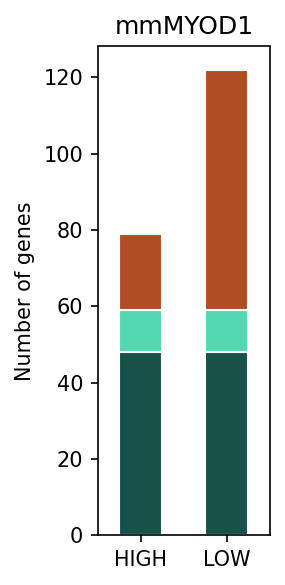

In [185]:
fig, ax = plt.subplots(figsize=(2, 4), dpi=150)

colors = {
    'match': '#175149',
    'mismatch': '#54D8B1',
    'unique_to_group': '#AF4E24',
}

ax = plot_df.plot(
    kind='bar',
    stacked=True,
    width=0.5,
    ax=ax,
    color=colors,
    ec='white',
)

ax.set_ylabel('Number of genes')
ax.set_xlabel('')
ax.set_title(f'{group_key}')
ax.tick_params(axis='x', rotation=0)
ax.get_legend().remove()

plt.tight_layout()
plt.show()

,mmMYOD1_high_G1S,mmMYOD1_low_G1S
ANP32E,-0.606470,0.576757
BIRC5,-0.588815,1.081817
CKS1B,-0.622493,0.556446
DLGAP5,-1.016875,0.756706
HSPA8,-1.157550,0.542897


(11, 2)


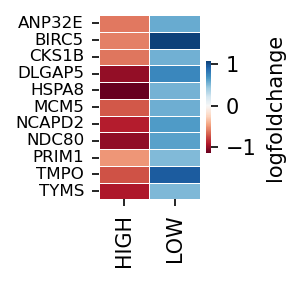

In [188]:
mdf = kdf[kdf['direction_consistency'] == 'mismatch'].copy()

mdf.head()

mdf = mdf.pivot(index='names', columns='group', values="logfoldchanges")
mdf.index.name = None
mdf.columns.name = None
display(mdf.head())
print(mdf.shape)

vmin = (mdf.min()).min()
vmax = (mdf.max()).max()

# plt.figure(figsize=(2, 3.5), dpi=150)
plt.figure(figsize=(2, len(mdf)*0.18), dpi=150)
ax = sns.heatmap(
    mdf,
    # cmap=custom_cmap,
    cmap="RdBu",
    linewidths=0.35,
    linecolor="white",
    # cbar_kws={"label": "logfoldchange", 'shrink': 0.5},
    cbar_kws={"label": "logfoldchange", 'shrink': 0.5},
    vmin=vmin,
    vmax=vmax,
    center=0,
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(["HIGH", "LOW"], rotation=90)

ax.set_yticks([i + 0.5 for i in range(len(mdf))])
ax.set_yticklabels(mdf.index.to_list(), fontsize=8, va='center')


plt.tight_layout()
plt.show()

In [191]:
dir_key = 'high'

groups_keep = [f'mmMYOD1_{dir_key}_G1S', f'siPRRX1/mmMYOD1_{dir_key}_G1S']

kdf = df[df['group'].isin(groups_keep)].copy()
print(kdf.shape)


# Step 1: build a per-gene summary of directions across groups
gene_summary = (
    kdf.groupby('names')
      .agg(
          n_groups=('group', 'nunique'),
          n_directions=('direction', lambda x: x.nunique()),
          direction_set=('direction', lambda x: set(x))
      )
      .reset_index()
)

# Step 2: define logic for consistency
def classify(row):
    if row['n_groups'] == 1:
        return 'unique_to_group'
    elif row['n_directions'] == 1:
        return 'match'
    else:
        return 'mismatch'

gene_summary['direction_consistency'] = gene_summary.apply(classify, axis=1)

# Step 3: map back to original dataframe
kdf = kdf.merge(
    gene_summary[['names', 'direction_consistency']],
    on='names',
    how='left'
)

display(kdf.head())


print(kdf['names'].nunique())

print("\n", kdf.groupby('group')['names'].nunique())

print("\n", kdf.groupby(['group', 'direction'])['names'].nunique())

print("\n", kdf.groupby('group')['direction_consistency'].value_counts())

(167, 12)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction,condition,exp_level,abs_lfc,direction_consistency
0,mmMYOD1_high_G1S,GMNN,23.052416,2.295428,1.391079e-117,9.874300e-116,0.769925,Control_G1S,up,mmMYOD1,HIGH,2.295428,match
1,mmMYOD1_high_G1S,PLK2,20.845648,3.490016,1.669341e-96,9.363212e-95,0.612030,Control_G1S,up,mmMYOD1,HIGH,3.490016,match
2,mmMYOD1_high_G1S,NES,18.075657,2.351126,4.956188e-73,1.939861e-71,0.592481,Control_G1S,up,mmMYOD1,HIGH,2.351126,match
3,mmMYOD1_high_G1S,MYC,17.782084,2.979373,9.729763e-71,3.738371e-69,0.538346,Control_G1S,up,mmMYOD1,HIGH,2.979373,match
4,mmMYOD1_high_G1S,FBXL7,13.908415,1.147300,5.631406e-44,1.333704e-42,0.718797,Control_G1S,up,mmMYOD1,HIGH,1.147300,match


113

 group
mmMYOD1_high_G1S            79
siPRRX1/mmMYOD1_high_G1S    88
Name: names, dtype: int64

 group                     direction
mmMYOD1_high_G1S          down         30
                          up           49
siPRRX1/mmMYOD1_high_G1S  down         10
                          up           78
Name: names, dtype: int64

 group                     direction_consistency
mmMYOD1_high_G1S          match                    52
                          unique_to_group          25
                          mismatch                  2
siPRRX1/mmMYOD1_high_G1S  match                    52
                          unique_to_group          34
                          mismatch                  2
Name: count, dtype: int64


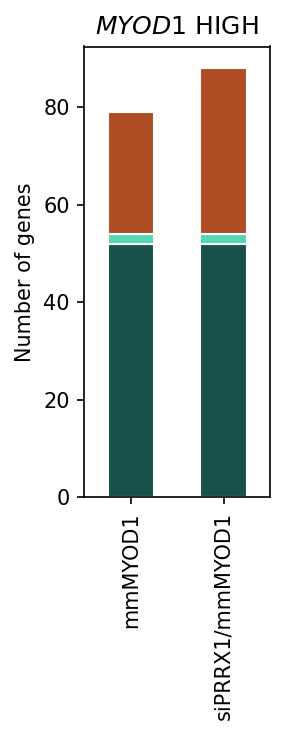

In [192]:
counts = kdf.groupby(['group', 'direction_consistency'], observed=True).size().reset_index(name='count')
plot_df = counts.pivot(index='group', columns='direction_consistency', values='count').fillna(0)

plot_df.index = plot_df.index.str.split('_').str[-3]

plot_df

fig, ax = plt.subplots(figsize=(2, 5), dpi=150)

colors = {
    'match': '#175149',
    'mismatch': '#54D8B1',
    'unique_to_group': '#AF4E24',
}

ax = plot_df.plot(
    kind='bar',
    stacked=True,
    width=0.5,
    ax=ax,
    color=colors,
    ec='white',
)

ax.set_ylabel('Number of genes')
ax.set_xlabel('')
ax.set_title(f'$MYOD1$ {dir_key.upper()}')
ax.tick_params(axis='x', rotation=90)
ax.get_legend().remove()

plt.tight_layout()
plt.show()

,mmMYOD1_high_G1S,siPRRX1/mmMYOD1_high_G1S
BIRC5,-0.588815,0.621688
DLGAP5,-1.016875,0.626647


(2, 2)


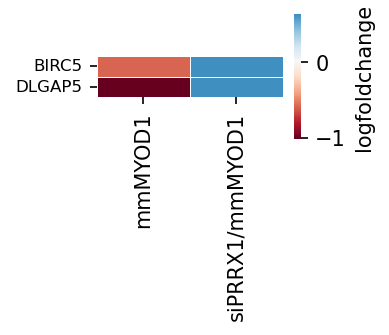

In [195]:
mdf = kdf[kdf['direction_consistency'] == 'mismatch'].copy()

mdf.head()

mdf = mdf.pivot(index='names', columns='group', values="logfoldchanges")
mdf.index.name = None
mdf.columns.name = None
display(mdf.head())
print(mdf.shape)

vmin = (mdf.min()).min()
vmax = (mdf.max()).max()

# plt.figure(figsize=(2, 3.5), dpi=150)
plt.figure(figsize=(2, len(mdf)*0.18), dpi=150)
ax = sns.heatmap(
    mdf,
    # cmap=custom_cmap,
    cmap="RdBu",
    linewidths=0.35,
    linecolor="white",
    # cbar_kws={"label": "logfoldchange", 'shrink': 0.5},
    cbar_kws={"label": "logfoldchange", 'shrink': 3},
    vmin=vmin,
    vmax=vmax,
    center=0,
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(["mmMYOD1", "siPRRX1/mmMYOD1"], rotation=90)

ax.set_yticks([i + 0.5 for i in range(len(mdf))])
ax.set_yticklabels(mdf.index.to_list(), fontsize=8, va='center', rotation=0)


plt.tight_layout()
plt.show()

# Stats

In [83]:
print(df.shape)
df.head()

(636, 12)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction,condition,exp_level,abs_lfc
73,mmMYOD1_high_G1S,GMNN,23.052416,2.295428,1.391079e-117,9.874300e-116,0.769925,Control_G1S,up,mmMYOD1,HIGH,2.295428
113,mmMYOD1_high_G1S,PLK2,20.845648,3.490016,1.669341e-96,9.363212e-95,0.612030,Control_G1S,up,mmMYOD1,HIGH,3.490016
202,mmMYOD1_high_G1S,NES,18.075657,2.351126,4.956188e-73,1.939861e-71,0.592481,Control_G1S,up,mmMYOD1,HIGH,2.351126
208,mmMYOD1_high_G1S,MYC,17.782084,2.979373,9.729763e-71,3.738371e-69,0.538346,Control_G1S,up,mmMYOD1,HIGH,2.979373
399,mmMYOD1_high_G1S,FBXL7,13.908415,1.147300,5.631406e-44,1.333704e-42,0.718797,Control_G1S,up,mmMYOD1,HIGH,1.147300


In [119]:
from scipy import stats
from itertools import combinations
from scipy.stats import shapiro, levene

In [112]:
# test normality, test homogeneity of variance

def normality_check(df, alpha=0.05, lfc_col='logfoldchanges', group_col='exp_level'):
    
    exp_levels = df[group_col].unique()
    
    for level in exp_levels:
        
        lfc = df[df[group_col] == level][lfc_col]
        
        stat1, p1 = stats.shapiro(lfc) # Shapiro-Wilk test
        stat2, p2 = stats.normaltest(lfc) # D’Agostino and Pearson’s test
        
        if p1 < alpha:
            sig1 = 'SIGNIFICANT (data is NOT normal)'
        else:
            sig1 = 'NOT SIGNIFICANT (data is normal)'
            
        if p2 < alpha:
            sig2 = 'SIGNIFICANT (data is NOT normal)'
        else:
            sig2 = 'NOT SIGNIFICANT (data is normal)'
        
        print(f'{level}:\tShapiro-Wilk p-val = {p1:.4e} {sig1},\tD’Agostino and Pearson’s p-val = {p2:.4e} {sig2}')

In [118]:
### mmMYOD1
tmp1 = df[df['condition'] == 'mmMYOD1'].copy()
print(tmp1.shape)

print('\n-------------- mmMYOD1 (raw logFC) --------------')
# raw logFC vals
normality_check(tmp1)

print('\n-------------- mmMYOD1 (absolute logFC) --------------')
# raw logFC vals
normality_check(tmp1, lfc_col='abs_lfc')



### siPRRX1/mmMYOD1
tmp2 = df[df['condition'] == 'siPRRX1/mmMYOD1'].copy()
print(tmp2.shape)

print('\n-------------- siPRRX1/mmMYOD1 (raw logFC) --------------')
# raw logFC vals
normality_check(tmp2)

print('\n-------------- siPRRX1/mmMYOD1 (absolute logFC) --------------')
# raw logFC vals
normality_check(tmp2, lfc_col='abs_lfc')

(300, 12)

-------------- mmMYOD1 (raw logFC) --------------
HIGH:	Shapiro-Wilk p-val = 2.9261e-02 SIGNIFICANT (data is NOT normal),	D’Agostino and Pearson’s p-val = 5.5031e-01 NOT SIGNIFICANT (data is normal)
LOW:	Shapiro-Wilk p-val = 6.0153e-10 SIGNIFICANT (data is NOT normal),	D’Agostino and Pearson’s p-val = 4.8075e-11 SIGNIFICANT (data is NOT normal)
MED:	Shapiro-Wilk p-val = 6.4766e-09 SIGNIFICANT (data is NOT normal),	D’Agostino and Pearson’s p-val = 6.1228e-08 SIGNIFICANT (data is NOT normal)

-------------- mmMYOD1 (absolute logFC) --------------
HIGH:	Shapiro-Wilk p-val = 1.4635e-07 SIGNIFICANT (data is NOT normal),	D’Agostino and Pearson’s p-val = 1.0584e-05 SIGNIFICANT (data is NOT normal)
LOW:	Shapiro-Wilk p-val = 3.0769e-07 SIGNIFICANT (data is NOT normal),	D’Agostino and Pearson’s p-val = 1.6657e-09 SIGNIFICANT (data is NOT normal)
MED:	Shapiro-Wilk p-val = 7.7534e-08 SIGNIFICANT (data is NOT normal),	D’Agostino and Pearson’s p-val = 3.3804e-06 SIGNIFICANT (data is NOT n

In [130]:
def manual_step_a(df, lfc_col='logfoldchanges', group_col='exp_level'):
    groups = df[group_col].unique()
    group_data = [df[df[group_col] == g][lfc_col] for g in groups]
    
    l_stat, l_p = stats.levene(*group_data)
    if l_p < 0.05:
        sig = 'SIGNIFICANT (unequal variances)'
    else:
        sig = 'NOT SIGNIFICANT (equal variances)'
    
    print(f"Levene's p-val: {l_p:.4e} {sig}")
    
    
    # 1. Global Test
    h_stat, p_global = stats.kruskal(*group_data)
    if p_global < 0.05:
        sig1 = 'SIGNIFICANT'
    else:
        sig1 = 'NOT SIGNIFICANT'
    
    print(f"Global Kruskal-Wallis p-value: {p_global:.4e} {sig1}\n") ### are any of the 3 groups (exp_levels) different?
    
    if p_global < 0.05:
        print("--- Pairwise Mann-Whitney U Tests (with Bonferroni) ---") ### comparing the "rank" (median) between 2 specific groups
        pairs = list(combinations(groups, 2))
        num_comparisons = len(pairs)
        
        for g1, g2 in pairs:
            d1 = df[df[group_col] == g1][lfc_col]
            d2 = df[df[group_col] == g2][lfc_col]
            
            stat, p_unadj = stats.mannwhitneyu(d1, d2, alternative='two-sided')
            
            # Manual Bonferroni Correction
            p_adj = min(p_unadj * num_comparisons, 1.0)
            
            print(f"{g1} vs {g2}: p-unadj={p_unadj:.4e}, p-adj={p_adj:.4e}")

In [145]:
### within condition (diffs between LOW/MED/HIGH)
print("Testing for differences between MYOD1 expression levels within each condition...\n")


### mmMYOD1
print("------------ mmMYOD1 ------------")
print("Raw logfoldchanges:")
manual_step_a(tmp1)
print("Absolute logfoldchanges:")
manual_step_a(tmp1, lfc_col='abs_lfc')


### siPRRX1mmMYOD1
print("\n------------ siPRRX1/mmMYOD1 ------------")
print("Raw logfoldchanges:")
manual_step_a(tmp2)
print("\n")
print("Absolute logfoldchanges:")
manual_step_a(tmp2, lfc_col='abs_lfc')

Testing for differences between MYOD1 expression levels within each condition...

------------ mmMYOD1 ------------
Raw logfoldchanges:
Levene's p-val: 2.0738e-11 SIGNIFICANT (unequal variances)
Global Kruskal-Wallis p-value: 7.0774e-02 NOT SIGNIFICANT

Absolute logfoldchanges:
Levene's p-val: 8.7808e-03 SIGNIFICANT (unequal variances)
Global Kruskal-Wallis p-value: 4.5755e-01 NOT SIGNIFICANT


------------ siPRRX1/mmMYOD1 ------------
Raw logfoldchanges:
Levene's p-val: 1.1365e-01 NOT SIGNIFICANT (equal variances)
Global Kruskal-Wallis p-value: 2.8007e-03 SIGNIFICANT

--- Pairwise Mann-Whitney U Tests (with Bonferroni) ---
HIGH vs LOW: p-unadj=1.0205e-03, p-adj=3.0616e-03
HIGH vs MED: p-unadj=4.4804e-02, p-adj=1.3441e-01
LOW vs MED: p-unadj=7.5484e-02, p-adj=2.2645e-01


Absolute logfoldchanges:
Levene's p-val: 3.1179e-01 NOT SIGNIFICANT (equal variances)
Global Kruskal-Wallis p-value: 1.5355e-02 SIGNIFICANT

--- Pairwise Mann-Whitney U Tests (with Bonferroni) ---
HIGH vs LOW: p-unadj

In [120]:
high_lfc = tmp1[tmp1['exp_level'] == 'HIGH']['logfoldchanges']
med_lfc = tmp1[tmp1['exp_level'] == 'MED']['logfoldchanges']
low_lfc = tmp1[tmp1['exp_level'] == 'LOW']['logfoldchanges']

# Testing the raw LFC distributions
# This detects differences in shape, variance, and median simultaneously
ad_stat, critical_values, p_val = stats.anderson_ksamp([high_lfc, med_lfc, low_lfc])
print(f"Anderson-Darling p-value: {p_val:.4e}")

# Specifically tests if the variance is different
# p < 0.05 means the variances are significantly different
stat, p_variance = stats.levene(high_lfc, med_lfc, low_lfc)
print(f"Levene's test for variance p-value: {p_variance:.4e}")

Anderson-Darling p-value: 1.0000e-03
Levene's test for variance p-value: 2.0738e-11


In [87]:
high_lfc = tmp1[tmp1['exp_level'] == 'HIGH']['abs_lfc']
med_lfc = tmp1[tmp1['exp_level'] == 'MED']['abs_lfc']
low_lfc = tmp1[tmp1['exp_level'] == 'LOW']['abs_lfc']

stat, p_magnitude = stats.kruskal(high_lfc, med_lfc, low_lfc)
print(f"Magnitude (Absolute LFC) p-value: {p_magnitude:.4e}")

# Specifically tests if the variance is different
# p < 0.05 means the variances are significantly different
stat, p_variance = stats.levene(high_lfc, med_lfc, low_lfc)
print(f"Levene's test for variance p-value: {p_variance:.4e}")

Magnitude (Absolute LFC) p-value: 4.5755e-01
Levene's test for variance p-value: 8.7808e-03


In [89]:
high_lfc = tmp2[tmp2['exp_level'] == 'HIGH']['logfoldchanges']
med_lfc = tmp2[tmp2['exp_level'] == 'MED']['logfoldchanges']
low_lfc = tmp2[tmp2['exp_level'] == 'LOW']['logfoldchanges']

# Testing the raw LFC distributions
# This detects differences in shape, variance, and median simultaneously
ad_stat, critical_values, p_val = stats.anderson_ksamp([high_lfc, med_lfc, low_lfc])
print(f"Anderson-Darling p-value: {p_val:.4e}")

# Specifically tests if the variance is different
# p < 0.05 means the variances are significantly different
stat, p_variance = stats.levene(high_lfc, med_lfc, low_lfc)
print(f"Levene's test for variance p-value: {p_variance:.4e}")

Anderson-Darling p-value: 2.1942e-03
Levene's test for variance p-value: 1.1365e-01


In [90]:
high_lfc = tmp2[tmp2['exp_level'] == 'HIGH']['abs_lfc']
med_lfc = tmp2[tmp2['exp_level'] == 'MED']['abs_lfc']
low_lfc = tmp2[tmp2['exp_level'] == 'LOW']['abs_lfc']

stat, p_magnitude = stats.kruskal(high_lfc, med_lfc, low_lfc)
print(f"Magnitude (Absolute LFC) p-value: {p_magnitude:.4e}")

# Specifically tests if the variance is different
# p < 0.05 means the variances are significantly different
stat, p_variance = stats.levene(high_lfc, med_lfc, low_lfc)
print(f"Levene's test for variance p-value: {p_variance:.4e}")

Magnitude (Absolute LFC) p-value: 1.5355e-02
Levene's test for variance p-value: 3.1179e-01


In [141]:
def manual_step_b(df_condition1, df_condition2, alpha=0.05, level='HIGH', lfc_col='logfoldchanges'):
    # Extract the LFCs for the specific MYOD1 level
    dist1 = df_condition1[df_condition1['exp_level'] == level][lfc_col]
    dist2 = df_condition2[df_condition2['exp_level'] == level][lfc_col]
    
    
    # Normality check
    cond1_stat, cond1_p = stats.shapiro(dist1)
    
    if cond1_p < alpha:
        cond1_norm = 'SIGNIFICANT (NOT normal)'
    else:
        cond1_norm = 'NOT SIGNIFICANT (normal)'
        
    cond2_stat, cond2_p = stats.shapiro(dist2)
    
    if cond2_p < alpha:
        cond2_norm = 'SIGNIFICANT (NOT normal)'
    else:
        cond2_norm = 'NOT SIGNIFICANT (normal)'
    
    
    # Variance check
    l_stat, p_lev = stats.levene(dist1, dist2)
    
    if p_lev < alpha:
        sig_lev = 'SIGNIFICANT (unequal variances)'
    else:
        sig_lev = 'NOT SIGNIFICANT (equal variances)'    
    
    
    # KS Test: Does the shape of the distribution change?
    ks_stat, ks_p = stats.ks_2samp(dist1, dist2)
    
    if ks_p < alpha:
        sig_ks = 'SIGNIFICANT'
    else:
        sig_ks = 'NOT SIGNIFICANT'
    
    # Mann-Whitney: Does the median shift?
    mw_stat, mw_p = stats.mannwhitneyu(dist1, dist2)
    
    if mw_p < alpha:
        sig_mw = 'SIGNIFICANT'
    else:
        sig_mw = 'NOT SIGNIFICANT'
    
    print(f"{level}")
    print(f"  Normality check (cond1): {cond1_p:.4e}  {cond1_norm}")
    print(f"  Normality check (cond2): {cond2_p:.4e}  {cond2_norm}")
    print(f"  Variance check: {p_lev:.4e}  {sig_lev}\n")
    print(f"  KS Test p: {ks_p:.4e}  {sig_ks}")
    print(f"  Mann-Whitney p: {mw_p:.4e}  {sig_mw}")

In [142]:
print("Testing for differences between conditions for each MYOD1 expression level...\n")

manual_step_b(tmp1, tmp2)
print("\n")
manual_step_b(tmp1, tmp2, level='MED')
print("\n")
manual_step_b(tmp1, tmp2, level='LOW')

Testing for differences between conditions for each MYOD1 expression level...

HIGH
  Normality check (cond1): 2.9261e-02  SIGNIFICANT (NOT normal)
  Normality check (cond2): 2.8306e-07  SIGNIFICANT (NOT normal)
  Variance check: 2.4061e-05  SIGNIFICANT (unequal variances)

  KS Test p: 4.1633e-03  SIGNIFICANT
  Mann-Whitney p: 2.0719e-01  NOT SIGNIFICANT


MED
  Normality check (cond1): 6.4766e-09  SIGNIFICANT (NOT normal)
  Normality check (cond2): 4.2660e-10  SIGNIFICANT (NOT normal)
  Variance check: 2.8004e-01  NOT SIGNIFICANT (equal variances)

  KS Test p: 2.2100e-01  NOT SIGNIFICANT
  Mann-Whitney p: 3.0725e-01  NOT SIGNIFICANT


LOW
  Normality check (cond1): 6.0153e-10  SIGNIFICANT (NOT normal)
  Normality check (cond2): 5.7524e-10  SIGNIFICANT (NOT normal)
  Variance check: 9.1996e-01  NOT SIGNIFICANT (equal variances)

  KS Test p: 2.8547e-03  SIGNIFICANT
  Mann-Whitney p: 5.5044e-03  SIGNIFICANT


In [143]:
manual_step_b(tmp1, tmp2, lfc_col='abs_lfc')
print("\n")
manual_step_b(tmp1, tmp2, level='MED', lfc_col='abs_lfc')
print("\n")
manual_step_b(tmp1, tmp2, level='LOW', lfc_col='abs_lfc')

HIGH
  Normality check (cond1): 1.4635e-07  SIGNIFICANT (NOT normal)
  Normality check (cond2): 1.0767e-08  SIGNIFICANT (NOT normal)
  Variance check: 1.4701e-01  NOT SIGNIFICANT (equal variances)

  KS Test p: 2.4493e-01  NOT SIGNIFICANT
  Mann-Whitney p: 1.2508e-01  NOT SIGNIFICANT


MED
  Normality check (cond1): 7.7534e-08  SIGNIFICANT (NOT normal)
  Normality check (cond2): 4.1612e-06  SIGNIFICANT (NOT normal)
  Variance check: 3.2987e-01  NOT SIGNIFICANT (equal variances)

  KS Test p: 3.2936e-01  NOT SIGNIFICANT
  Mann-Whitney p: 5.3928e-01  NOT SIGNIFICANT


LOW
  Normality check (cond1): 3.0769e-07  SIGNIFICANT (NOT normal)
  Normality check (cond2): 1.0717e-04  SIGNIFICANT (NOT normal)
  Variance check: 8.1514e-01  NOT SIGNIFICANT (equal variances)

  KS Test p: 3.1178e-03  SIGNIFICANT
  Mann-Whitney p: 4.7034e-03  SIGNIFICANT
